In [1]:
# ============================
# F5 — Week 05: BO update (MAXIMISE)
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================

# ----------------------------
# Imports (keep all at top)
# ----------------------------
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*lbfgs failed to converge.*")

In [2]:
# ----------------------------
# 0) Config
# ----------------------------
# Your project paths (as requested)
INPUTS_PATH = "data/F5/initial_inputs.npy"
OUTPUTS_PATH = "data/F5/initial_outputs.npy"

# Fallback to local uploaded paths (handy in Colab / sandbox)
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# Domain
BOUNDS = np.array([[0.0, 1.0]] * 4)

# Acquisition / sampling
RANDOM_SEED = 42
BATCH_SIZE = 1                  # tutor wants ONE row
N_CANDIDATES = 60000            # candidate pool size
LOCAL_FRAC = 0.90               # mostly local refinement
LOCAL_STD = 0.025               # tighter than last week (ultra-fine search)
KAPPA = 0.20                    # more exploitation than Week 04
MIN_DIST_TO_EXISTING = 0.015    # avoid resubmitting near-duplicates

In [3]:
# ----------------------------
# 1) Load
# ----------------------------
def resolve_path(primary: str, fallback: str) -> str:
    return primary if os.path.exists(primary) else fallback

X_path = resolve_path(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y_path = resolve_path(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

X = np.load(X_path)
y = np.load(y_path)

assert X.ndim == 2 and X.shape[1] == 4, f"Expected X shape (n,4). Got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,). Got {y.shape}"
assert np.all(X >= 0.0) and np.all(X <= 1.0), "Expected X within [0,1]^4"

n = X.shape[0]
print(f"Loaded F5 dataset: n={n} points, d={X.shape[1]} dims.")
print(f"y stats: min={y.min():.6g}, median={np.median(y):.6g}, max={y.max():.6g}")

# Transform (stabilise extreme range)
y_t = np.log1p(y)  # log(1+y)

Loaded F5 dataset: n=24 points, d=4 dims.
y stats: min=0.11294, median=71.4389, max=3240.01


In [4]:
# ----------------------------
# 2) Surrogate (GP + ARD)
# ----------------------------
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.ones(X.shape[1]),
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,            # nugget for numerical stability
    normalize_y=True,
    n_restarts_optimizer=8,
    random_state=RANDOM_SEED
)

gp.fit(X, y_t)

print("\nTrained GP kernel:")
print(gp.kernel_)

# Extract ARD lengthscales (interpretability)
try:
    lengthscales = gp.kernel_.k2.length_scale
except Exception:
    lengthscales = None


Trained GP kernel:
2.09**2 * Matern(length_scale=[2.09, 0.633, 1.3, 0.798], nu=2.5)


In [5]:
# ----------------------------
# 3) Acquisition (UCB) → pick ONE next X row
# ----------------------------
rng = np.random.default_rng(RANDOM_SEED)

best_idx = int(np.argmax(y_t))
x_best = X[best_idx].copy()

n_local = int(N_CANDIDATES * LOCAL_FRAC)
n_global = N_CANDIDATES - n_local

# Local candidates: around current best
cand_local = x_best + rng.normal(0.0, LOCAL_STD, size=(n_local, X.shape[1]))
cand_local = np.clip(cand_local, BOUNDS[:, 0], BOUNDS[:, 1])

# Global candidates: uniform in domain (anti-premature-convergence guard)
cand_global = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(n_global, X.shape[1]))

CAND = np.vstack([cand_local, cand_global])

mu, std = gp.predict(CAND, return_std=True)          # in log1p space
ucb = mu + KAPPA * std

# Sort by acquisition value (descending)
order = np.argsort(-ucb)

def min_dist_to_set(x: np.ndarray, X_set: np.ndarray) -> float:
    # Euclidean distance to nearest point in X_set
    d = np.linalg.norm(X_set - x[None, :], axis=1)
    return float(d.min())

# Choose first high-UCB candidate not too close to existing points
x_next = None
for idx in order:
    x_cand = CAND[idx]
    if min_dist_to_set(x_cand, X) >= MIN_DIST_TO_EXISTING:
        x_next = x_cand
        break

# If everything was too close (rare), just take the top-UCB point
if x_next is None:
    x_next = CAND[order[0]]

X_next_batch = x_next.reshape(1, -1)



Diagnostics (train, log1p scale):
 - RMSE: 5.17208e-06
 - R2:   1
 - Residual mean: 1.25e-08, std: 5.17e-06

Region / diversity checks:
 - Current best x (argmax observed): [0.236344 0.904546 0.999999 0.988293]
 - Proposed x_next distance to existing nearest: 0.0989963
 - Proposed x_next distance to current best:     0.0989963


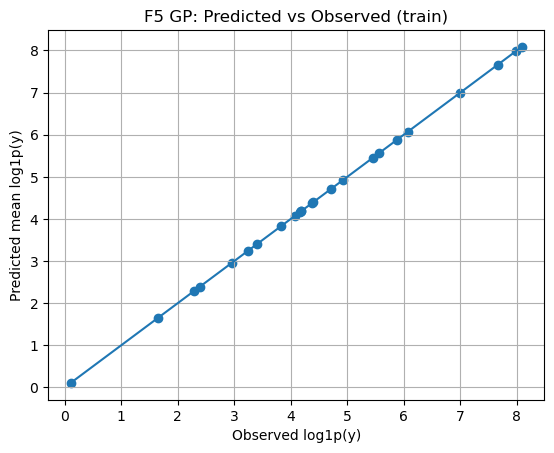

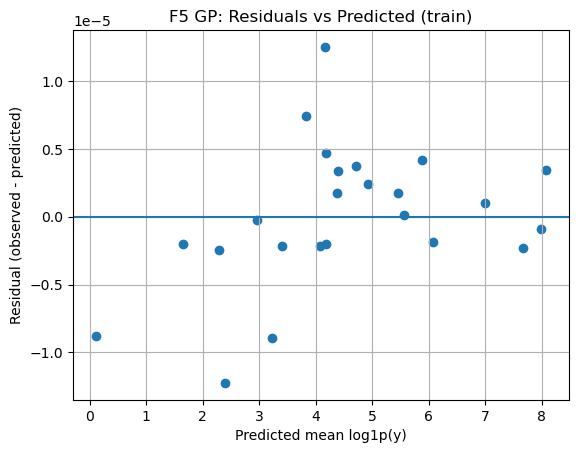

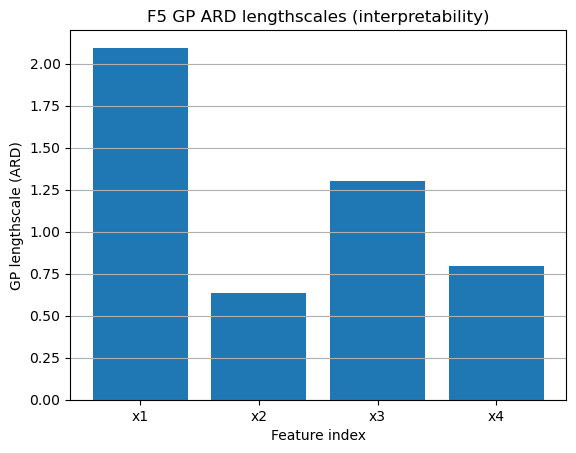

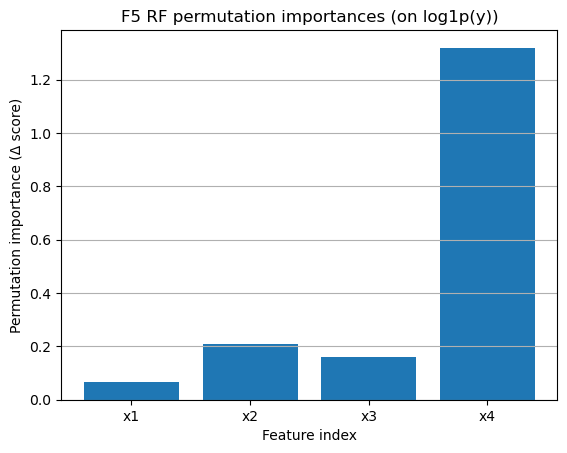

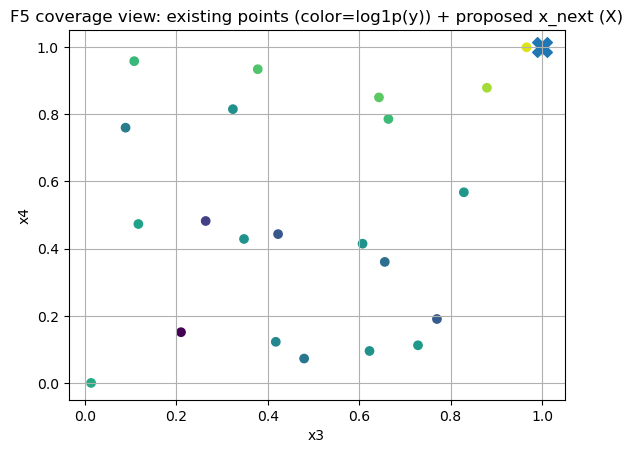

In [6]:
# ----------------------------
# 4) Diagnostics
# ----------------------------
mu_train, std_train = gp.predict(X, return_std=True)

rmse = np.sqrt(mean_squared_error(y_t, mu_train))
r2 = r2_score(y_t, mu_train)
resid = (y_t - mu_train)

print("\nDiagnostics (train, log1p scale):")
print(f" - RMSE: {rmse:.6g}")
print(f" - R2:   {r2:.6g}")
print(f" - Residual mean: {resid.mean():.3g}, std: {resid.std():.3g}")

# Distances / region checks
d_next = min_dist_to_set(x_next, X)
d_best = float(np.linalg.norm(x_next - x_best))
print("\nRegion / diversity checks:")
print(f" - Current best x (argmax observed): {x_best}")
print(f" - Proposed x_next distance to existing nearest: {d_next:.6g}")
print(f" - Proposed x_next distance to current best:     {d_best:.6g}")

# Predicted vs observed (transformed)
plt.figure()
plt.scatter(y_t, mu_train)
mn = min(y_t.min(), mu_train.min())
mx = max(y_t.max(), mu_train.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log1p(y)")
plt.ylabel("Predicted mean log1p(y)")
plt.title("F5 GP: Predicted vs Observed (train)")
plt.grid(True)

# Residuals vs predicted
plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0.0)
plt.xlabel("Predicted mean log1p(y)")
plt.ylabel("Residual (observed - predicted)")
plt.title("F5 GP: Residuals vs Predicted (train)")
plt.grid(True)

# ARD lengthscales (smaller => more sensitive)
if lengthscales is not None:
    plt.figure()
    plt.bar(np.arange(1, 5), lengthscales)
    plt.xlabel("Feature index")
    plt.ylabel("GP lengthscale (ARD)")
    plt.title("F5 GP ARD lengthscales (interpretability)")
    plt.xticks([1, 2, 3, 4], ["x1", "x2", "x3", "x4"])
    plt.grid(True, axis="y")

# Optional: permutation feature importance via RF (quick, robust “importance” view)
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_SEED,
    min_samples_leaf=1
)
rf.fit(X, y_t)
perm = permutation_importance(rf, X, y_t, n_repeats=30, random_state=RANDOM_SEED)
imp_mean = perm.importances_mean
imp_std = perm.importances_std

plt.figure()
plt.bar(np.arange(1, 5), imp_mean)
plt.xlabel("Feature index")
plt.ylabel("Permutation importance (Δ score)")
plt.title("F5 RF permutation importances (on log1p(y))")
plt.xticks([1, 2, 3, 4], ["x1", "x2", "x3", "x4"])
plt.grid(True, axis="y")

# “Are we stuck?” quick 2D slice view on dominant dims (x3,x4), show points + x_next
plt.figure()
plt.scatter(X[:, 2], X[:, 3], c=y_t)
plt.scatter([x_next[2]], [x_next[3]], marker="X", s=200)
plt.xlabel("x3")
plt.ylabel("x4")
plt.title("F5 coverage view: existing points (color=log1p(y)) + proposed x_next (X)")
plt.grid(True)

plt.show()


In [7]:
# ----------------------------
# 5) Output (submit ONE row)
# ----------------------------
np.set_printoptions(precision=6, suppress=True)

print("\nSuggested NEXT batch (shape (1,4)):")
print(X_next_batch)

print("\nSingle best NEXT point (submit this ONE line):")
print(X_next_batch[0])

# Context only (NOT for submission): predicted yield on original scale
pred_log, pred_std = gp.predict(X_next_batch, return_std=True)
pred_mean_y = np.expm1(pred_log)[0]
print("\nContext (not for submission):")
print(f" - Predicted mean yield (approx): {pred_mean_y:.6g} (from expm1(pred_log_mean))")
print(f" - Predicted std in log-space:    {pred_std[0]:.6g}")


Suggested NEXT batch (shape (1,4)):
[[0.212855 1.       1.       1.      ]]

Single best NEXT point (submit this ONE line):
[0.212855 1.       1.       1.      ]

Context (not for submission):
 - Predicted mean yield (approx): 3865.93 (from expm1(pred_log_mean))
 - Predicted std in log-space:    0.310725
